
# **Machine Learning I Project**
## Hand Gesture Classification using Mediapipe Landmarks

In [2]:
import sys
sys.version

'3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]'


### Importing dependencies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request

### Loading the dataset

In [4]:
def load_HAGRID(path= "./datasets/hand_landmarks_data.csv"):
  dataset_path = Path(path)
  if not dataset_path.is_file():
    Path("./datasets").mkdir(parents= True, exist_ok= True)
    url = "https://raw.githubusercontent.com/MohamedShaaban-GAD/Hand-Gesture-Classifier-with-Mediapipe-Landmarks/refs/heads/main/hand_landmarks_data%20-%20hand_landmarks_data.csv"
    urllib.request.urlretrieve(url, dataset_path)
  return pd.read_csv(dataset_path)
original_hagrid = load_HAGRID()

### Exploring and Visualizing HAGRID dataset

In [5]:
data = original_hagrid.copy()
data.sample(8)

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
22211,136.138950,265.934387,2.210000e-07,139.853073,261.061676,-0.005431,142.062504,255.270218,-0.008641,145.746815,...,128.929825,252.531601,-0.014158,131.327751,254.987946,-0.013915,132.913685,257.446564,-0.011333,three2
11542,269.208183,223.407623,2.070000e-07,257.037254,221.391647,-0.013010,246.857987,215.419464,-0.021913,238.294258,...,278.960609,184.709930,-0.027625,279.259049,178.564346,-0.029101,279.133690,173.107529,-0.030061,palm
8589,97.064392,196.538467,8.480000e-08,105.914257,195.055313,-0.009523,115.205006,191.346466,-0.015880,121.498192,...,90.633923,160.378357,-0.027326,89.876850,153.851608,-0.029112,90.057644,148.476791,-0.029585,ok
22934,251.558716,292.554153,3.230000e-07,238.595490,287.813576,-0.012898,227.389938,279.266533,-0.024498,217.780884,...,264.084930,280.916634,-0.048069,257.568909,285.839172,-0.044558,253.981552,288.369324,-0.040078,three2
5094,109.637512,288.916534,3.340000e-07,122.244347,283.946472,-0.018846,131.985683,273.658844,-0.026650,125.615478,...,91.381617,247.074844,-0.031427,87.650608,240.636948,-0.035150,84.685249,234.440216,-0.037122,four
16340,140.634396,177.273438,-2.680000e-08,146.102177,172.268509,-0.010431,147.658607,165.110367,-0.013616,142.673561,...,130.956780,150.670624,-0.010106,128.379925,146.959595,-0.010383,127.192474,143.676849,-0.008152,rock
18092,114.134228,142.526410,1.470000e-07,123.725784,138.172403,-0.006899,128.312828,129.134537,-0.007862,129.865356,...,103.055775,109.239546,-0.012279,103.161587,103.314674,-0.013998,103.579159,98.145762,-0.014719,stop
17056,341.795837,177.275139,2.240000e-09,335.921631,174.728908,-0.004808,332.767731,168.912506,-0.007093,332.011658,...,348.708832,157.468460,-0.006874,348.214661,154.568184,-0.006510,347.310913,152.441265,-0.006368,stop


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [7]:
data.isna().sum().to_string()

'x1       0\ny1       0\nz1       0\nx2       0\ny2       0\nz2       0\nx3       0\ny3       0\nz3       0\nx4       0\ny4       0\nz4       0\nx5       0\ny5       0\nz5       0\nx6       0\ny6       0\nz6       0\nx7       0\ny7       0\nz7       0\nx8       0\ny8       0\nz8       0\nx9       0\ny9       0\nz9       0\nx10      0\ny10      0\nz10      0\nx11      0\ny11      0\nz11      0\nx12      0\ny12      0\nz12      0\nx13      0\ny13      0\nz13      0\nx14      0\ny14      0\nz14      0\nx15      0\ny15      0\nz15      0\nx16      0\ny16      0\nz16      0\nx17      0\ny17      0\nz17      0\nx18      0\ny18      0\nz18      0\nx19      0\ny19      0\nz19      0\nx20      0\ny20      0\nz20      0\nx21      0\ny21      0\nz21      0\nlabel    0'

Good, there is no missing data in our dataset. what a relief😌

## Spliting data into train and test sets

In [8]:
features = data.drop(["label"], axis=1)
labels = data['label']

In [9]:
labels.unique()

array(['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one',
       'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted',
       'three', 'three2', 'two_up', 'two_up_inverted'], dtype=object)

In [10]:
from sklearn.model_selection import train_test_split
train_features, test_features,  train_labels , test_labels = train_test_split(
                                                                            features,
                                                                            labels,
                                                                            test_size=.2,
                                                                            random_state= 42,
                                                                            stratify=labels)    ###

In [11]:
len(train_labels)

20540

In [12]:
# training_features, traning_labels, validation_features, validation_labels = train_test_split(train_features, train_labels, test_size=.1 ) # No need for creating a validation seg as it will be atoumatically createed later on in the cv

## Preprocessing

In [13]:
x = [col for col in data.columns if "x" in col]
y = [col for col in data.columns if "y" in col]
z = [col for col in data.columns if "z" in col]

In [14]:
def normalize(data):
  data= data.copy()
  data[x] = data[x].subtract(data['x1'], axis = 0) / data['x13'].values.reshape(-1,1)
  data[y] = data[y].subtract(data['y1'], axis = 0) / data['y13'].values.reshape(-1,1)
  return data

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
train_labels_encoded = encoder.fit_transform(train_labels)
test_labels_encoded = encoder.transform(test_labels)


In [16]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
                        ("normalized",  FunctionTransformer(normalize, validate= False, feature_names_out= "one-to-one")),
                        # ("scale" , StandardScaler())
                        ])


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [18]:
from xgboost import XGBClassifier

In [19]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier())
])

In [20]:
# svc_param_dist = [{
#         "model" : [SVC()],
#         "model__C" : uniform(.1, 500),
#         "model__kernel" : ['rbf', 'linear'],
#         "model__gamma" : uniform(.01, .1)
#     }
# ]

# svc_best_classifier = SVC(gamma= "auto", C= 130, kernel= 'rbf')

# svc_pipeline = Pipeline([
#     ("preprocessing", preprocessor),
#     ("model", svc_best_classifier)
#     ])
# svc_pipeline.fit(train_features, train_labels_encoded)

# svc_pipeline.score(test_features, test_labels_encoded)

In [20]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import randint, uniform

param_dist = [
    {
        "model" : [XGBClassifier(
            objective = 'multi:softprob',
            eval_metric = 'logloss',
            use_label_encoder = True,
            random_state= 42
        )
        ],
        "model__n_estimators" : randint(100,500),
        "model__max_depth" : randint(3, 10),
        "model__learning_rate" : uniform(.01, .3),
        "model__subsample" : uniform(.6 , .4),
        "model__colsample_bytree" : uniform(.6 , .4)

    },

    {
        "model" : [SVC(gamma = "auto")],
        "model__C" : uniform(.1, 20),
        "model__kernel" : ['rbf', 'linear']
    },

    {
        "model" :[RandomForestClassifier(random_state= 42)],
        "model__n_estimators": randint(50, 300),
        "model__max_depth" : randint(5, 30)
    },

    {
        "model" : [LogisticRegression(
            solver="lbfgs",
            max_iter=1000
        )],
        "model__C" : uniform(.01, 100)
    }
]




In [21]:
# svc_random_search = RandomizedSearchCV(
#     estimator = pipeline,
#     param_distributions = svc_param_dist,
#     cv = 5,
#     n_iter= 60,
#     random_state = 42,
#     n_jobs = -1,
#     scoring= 'accuracy'

# )

In [22]:
# svc_random_search.fit(train_features, train_labels)

# svc_best_model = svc_random_search.best_estimator_

# print(svc_random_search.best_params_)
# print(svc_random_search.best_score_)

# svc_test_score = svc_best_model.score(test_features, test_labels_encoded)
# print("Test accuracy:", svc_test_score)

In [ ]:
# halving_search = HalvingRandomSearchCV(
#     estimator = pipeline,
#     param_distributions = param_dist,
#     factor = 2,
#     cv = 5,
#     n_candidates= 120,
#     random_state = 42,
#     n_jobs = -1,
#     scoring= 'accuracy'

# )

In [ ]:
# halving_search.fit(train_features, train_labels_encoded)

# best_model = halving_search.best_estimator_

# print(halving_search.best_params_)
# print(halving_search.best_score_)

# test_score = best_model.score(test_features, test_labels_encoded)
# print("Test accuracy:", test_score)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), 'model__colsample_bytree': np.float64(0.9947547746402069), 'model__learning_rate': np.float64(0.24167343078899722), 'model__max_depth': 6, 'model__n_estimators': 235, 'model__subsample': np.float64(0.602208846

In [23]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator = pipeline,
    param_distributions = param_dist,
    cv = 5,
    n_iter = 80,
    random_state = 42,
    n_jobs = -1,
    scoring= 'accuracy'

)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

random_search.fit(train_features, train_labels_encoded)

best_model = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

test_score = best_model.score(test_features, test_labels_encoded)
print("Test accuracy:", test_score)



c:\Users\4k\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\4k\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:26:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), 'model__colsample_bytree': np.float64(0.9862528132298237), 'model__learning_rate': np.float64(0.2525192044349383), 'model__max_depth': 3, 'model__n_estimators': 445, 'model__subsample': np.float64(0.6390688456

In [25]:
results_df = pd.DataFrame(random_search.cv_results_)

top5_estimators = results_df.sort_values("rank_test_score").head(5)
(top5_estimators[["rank_test_score", "mean_test_score", "params"]])

,rank_test_score,mean_test_score,params
15,1,0.975852,"{'model': XGBClassifier(base_score=None, boost..."
27,2,0.974586,"{'model': XGBClassifier(base_score=None, boost..."
6,3,0.974002,"{'model': XGBClassifier(base_score=None, boost..."
32,4,0.973807,"{'model': XGBClassifier(base_score=None, boost..."
71,5,0.973466,"{'model': XGBClassifier(base_score=None, boost..."


Classification Report
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.98      0.99      0.99       189
           four       0.97      0.98      0.97       327
           like       0.98      0.99      0.99       287
           mute       0.96      0.97      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.96      0.95      0.96       253
           palm       0.96      0.97      0.96       330
          peace       0.97      0.92      0.94       288
 peace_inverted       0.99      0.96      0.97       299
           rock       1.00      0.99      0.99       292
           stop       0.93      0.96      0.95       296
  stop_inverted       0.99      0.99      0.99       314
          three       0.99      0.97      0.98       291
         three2       0.99      0.98      0.98       331
        

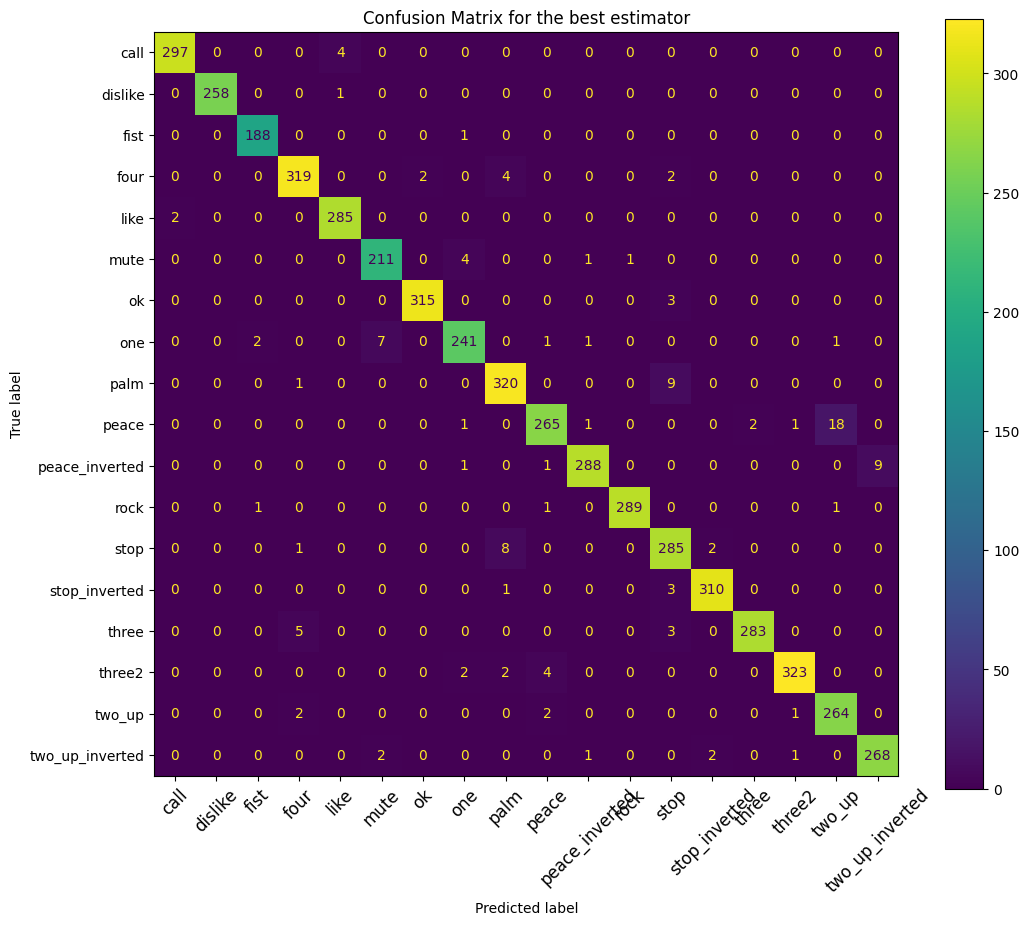

In [27]:
preds_encoded = best_model.predict(test_features)

print(f"=================================\nClassification Report\n=================================")
report = classification_report(test_labels_encoded, preds_encoded, target_names=encoder.classes_)
print(report)

print(f"=================================\nconfusion matrix\n=================================")
fig, ax = plt.subplots(figsize= (12,10))
model_confusion_matrix = confusion_matrix(test_labels_encoded, preds_encoded)
disp = ConfusionMatrixDisplay(model_confusion_matrix, display_labels= encoder.classes_)
disp.plot(ax=ax)
plt.xticks(rotation = 45, fontsize= 12)
plt.title("Confusion Matrix for the best estimator")
plt.show()

In [79]:
# from sklearn.model_selection import GridSearchCV

# param_grid = [
#     {
#         "model" : [XGBClassifier(
#             objective = 'multi:softprob',
#             eval_metric = 'logloss',
#             use_label_encoder = False,
#             random_state= 42
#         )
#         ],
#         "model__n_estimators" : [200, 250, 300],
#         "model__max_depth" : [3, 5, 7],
#         "model__learning_rate" : [.15, 22, .25],
#         "model__subsample" : [0.762],
#         "model__colsample_bytree" : [0.712]

#     },

#     {
#         "model" : [SVC(gamma= 0.05)],
#         "model__C" : [.1, 10, 100,150],
#         "model__kernel" : ['rbf', 'linear']
#     },

#     {
#         "model" :[RandomForestClassifier(random_state= 42)],
#         "model__n_estimators": [100, 200, 300],
#         "model__max_depth" : [5,10]
#     },

#     {
#         "model" : [LogisticRegression(
#             solver="lbfgs",
#             max_iter=1000
#         )],
#         "model__C" : [.01, 1, 100]
#     }
# ]

# grid_search = GridSearchCV(
#     pipeline,
#     param_grid= param_grid,
#     cv = 5,
#     scoring = 'accuracy'
# )

# grid_search.fit(train_features, train_labels_encoded)

# grid_best_model = grid_search.best_estimator_
# print(grid_search.best_params_)

# print(grid_best_model.score(test_features, test_labels_encoded))
# print(f'test accuracy: {test_score}')



In [28]:
import joblib

joblib.dump(best_model, "gestures_model.pkl")

['gestures_model.pkl']

In [23]:
from cv2.aruco import GridBoard
import cv2
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_hands_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode = False,
    max_num_hands = 1,
    min_detection_confidence = .5,
    min_tracking_confidence = .5

)

def extract_landmarks(frame):
  frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
  results = hands.process(frame_rgb)

  if results.multi_hand_landmarks:
    hand = results.multi_hand_landmarks[0]

    landmarks = []

    for lm in hand.landmark:
      landmarks.extend([lm.x, lm.y, lm.z])

    return np.array(landmarks)

  return None



In [ ]:
cap = cv2.VideoCapture("./test_video/hand_gestures.mp4")

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    landmarks = extract_landmarks(frame)

    if landmarks is not None:
        print(landmarks)

    cv2.imshow("Video", frame) 

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

[ 2.92459041e-01  1.01748919e+00 -1.55893289e-08  3.37451071e-01
  9.86203611e-01 -3.79189886e-02  3.78702462e-01  9.10995126e-01
 -6.31634891e-02  3.82231176e-01  8.60667706e-01 -8.66176784e-02
  3.71104449e-01  8.02766740e-01 -1.09202154e-01  3.50806355e-01
  7.24891067e-01 -5.14335930e-02  3.60757411e-01  5.99081755e-01
 -8.94638300e-02  3.64178210e-01  5.20120680e-01 -1.09427333e-01
  3.64498079e-01  4.52089161e-01 -1.21753365e-01  2.90684521e-01
  7.25280166e-01 -5.04728556e-02  2.96085060e-01  7.61794567e-01
 -9.96084884e-02  3.23050678e-01  8.72091770e-01 -1.06745467e-01
  3.38614762e-01  9.07956958e-01 -1.01759233e-01  2.40443096e-01
  7.68438935e-01 -5.34173846e-02  2.49495149e-01  8.42433691e-01
 -1.01129510e-01  2.80584663e-01  9.30350304e-01 -8.97194743e-02
  2.95401365e-01  9.43425119e-01 -7.15340450e-02  1.95897222e-01
  8.29172790e-01 -5.94612733e-02  2.01518625e-01  8.83496881e-01
 -8.92608836e-02  2.28626803e-01  9.50366378e-01 -7.75365010e-02
  2.40833506e-01  9.59163

In [21]:
import joblib

In [24]:
model = joblib.load("./gestures_model.pkl")

cam_cap = cv2.VideoCapture(0)

while True:
    ret, frame = cam_cap.read()

    if not ret:
        break

    landmarks = extract_landmarks(frame)

    if landmarks is not None:
        cols = train_features.columns
        landmarks = landmarks.reshape(1, -1)
        landmarks_df = pd.DataFrame(landmarks, columns= cols)
        prediction  = encoder.inverse_transform(model.predict(landmarks_df))[0]
        
        
        cv2.putText(
            frame,
            prediction,
            (10,50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,255,0),
            3
        )

        cv2.imshow("Gesture Recognition", frame)

        if cv2.waitKey(1) & 0xFF == 27:
            break
cam_cap.release()
cv2.destroyAllWindows()


: 

In [93]:
import  sys

sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'